# Кластеризация сигналов сцинтилляционного детектора
## Kaggle: Signal Types Classification

## Описание задачи

Цель данной работы — автоматическая кластеризация 23 479 сигналов, полученных со сцинтилляционного детектора, на основе их параметров. Необходимо разделить сигналы на три кластера:

- **Кластер 0** — гамма-кванты (γ)
- **Кластер 1** — нейтроны (n)  
- **Кластер 2** — аномальные / неидентифицируемые сигналы

Задача решается методами машинного обучения без учителя (кластеризация) с последующей интерпретацией результатов.

## Научная и практическая значимость

Современные задачи ядерной энергетики, радиационного контроля, фундаментальной и прикладной физики требуют высокоточной регистрации и анализа излучения различной природы. Важной составляющей является возможность отделения гамма-квантов от нейтронов в условиях сложного фонового окружения.

Сцинтилляционные детекторы на основе органических кристаллов (например, паратерфенил) обладают высокой чувствительностью и активно применяются:
- при контроле состояния отработанного ядерного топлива
- в системах радиационного мониторинга
- в физических экспериментах по регистрации антинейтрино и редких событий
- в медицине и промышленности

Автоматическая классификация сигналов — нетривиальная задача, так как сигналы могут перекрываться, иметь сложную форму, шумы и вариации. Применение методов кластеризации позволяет:
- автоматизировать распознавание сигналов разного типа
- улучшить точность выделения физических компонент
- выявлять аномальные сигналы и неисправности
- заложить основу для онлайн-анализа в реальном времени

## Исходные данные

Набор сигналов, каждый из которых описывается вектором признаков (характеристики сигнала: временные параметры, амплитудные показатели, статистические и производные метрики).

## Задача

Кластеризовать сигналы на три кластера с физически обоснованной интерпретацией.


## 1. Импорт библиотек

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy.optimize import curve_fit
from scipy.stats import gaussian_kde

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (silhouette_score,
                              calinski_harabasz_score,
                              davies_bouldin_score)

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams.update({'figure.dpi': 100, 'font.size': 11})

## 2. Загрузка данных


In [52]:
raw = pd.read_csv(
    'Run200_Wave_0_1.txt',
    sep=' ',
    header=None,
    skipinitialspace=True
)
raw = raw.drop([0, 1, 2, 3, 504], axis=1, errors='ignore')
raw.columns = list(range(500))
signals = (2**14 - raw - 1560).clip(lower=0)

print(f"Размер датасета:       {signals.shape}")
print(f"Сигналов:              {signals.shape[0]:,}")
print(f"Отсчётов на сигнал:    {signals.shape[1]}")
print(f"Пропущенных значений:  {signals.isna().sum().sum()}")

Размер датасета:       (23479, 500)
Сигналов:              23,479
Отсчётов на сигнал:    500
Пропущенных значений:  0


## 3. Анализ данных


In [53]:
peak_positions = signals.values.argmax(axis=1)
amplitudes     = signals.values.max(axis=1)
baseline_means = signals.values[:, :50].mean(axis=1)
baseline_stds  = signals.values[:, :50].std(axis=1) + 1e-6
snr_all        = (amplitudes - baseline_means) / baseline_stds

display(pd.DataFrame({
    'Позиция пика': peak_positions,
    'Амплитуда':    amplitudes,
    'Базовая линия':baseline_means,
    'SNR':          snr_all,
}).describe().round(2))

print(f"\nАномальная позиция пика (> 200): {(peak_positions > 200).sum()}")
print(f"Низкий SNR (< 5):                {(snr_all < 5).sum()}")

,Позиция пика,Амплитуда,Базовая линия,SNR
count,23479.00,23479.00,23479.00,23479.00
mean,149.63,1836.14,1.69,996.88
std,2.49,2389.31,0.57,1329.77
min,145.00,105.00,0.14,43.03
25%,149.00,309.00,1.28,164.97
50%,150.00,814.00,1.66,432.84
75%,151.00,2316.00,2.06,1250.20
max,472.00,14824.00,5.08,11932.97



Аномальная позиция пика (> 200): 1
Низкий SNR (< 5):                0


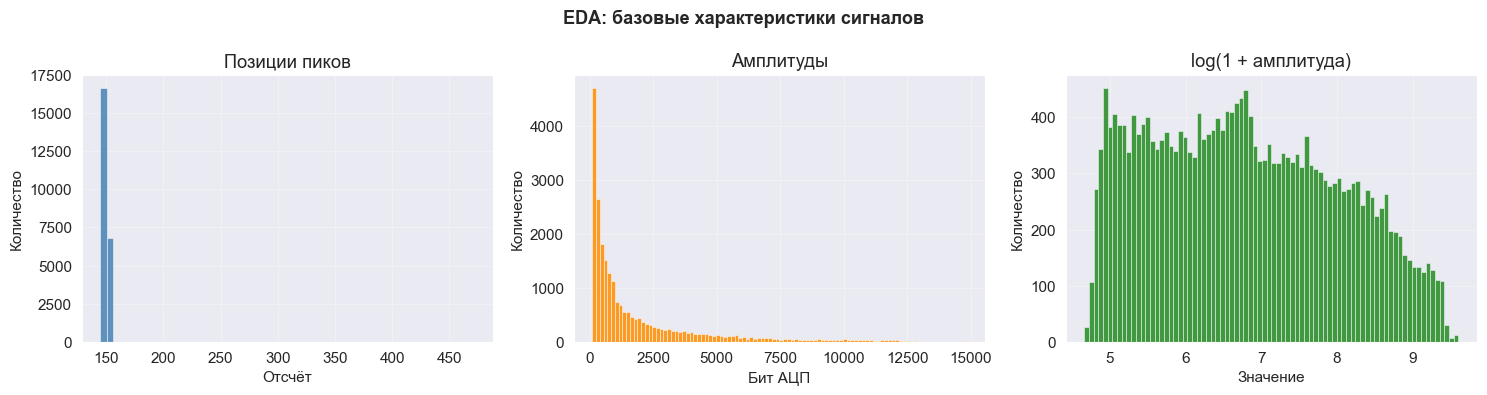

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('EDA: базовые характеристики сигналов', fontsize=13, fontweight='bold')

axes[0].hist(peak_positions, bins=60, color='steelblue', alpha=0.85, edgecolor='white', lw=0.4)
axes[0].set_title('Позиции пиков'); axes[0].set_xlabel('Отсчёт')
axes[0].set_ylabel('Количество'); axes[0].grid(True, alpha=0.3)

axes[1].hist(amplitudes, bins=100, color='darkorange', alpha=0.85, edgecolor='white', lw=0.4)
axes[1].set_title('Амплитуды'); axes[1].set_xlabel('Бит АЦП')
axes[1].set_ylabel('Количество'); axes[1].grid(True, alpha=0.3)

axes[2].hist(np.log1p(amplitudes), bins=80, color='forestgreen', alpha=0.85, edgecolor='white', lw=0.4)
axes[2].set_title('log(1 + амплитуда)'); axes[2].set_xlabel('Значение')
axes[2].set_ylabel('Количество'); axes[2].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

Пики стабильно в районе отсчетов 145-155.

Проверим форму сигналов

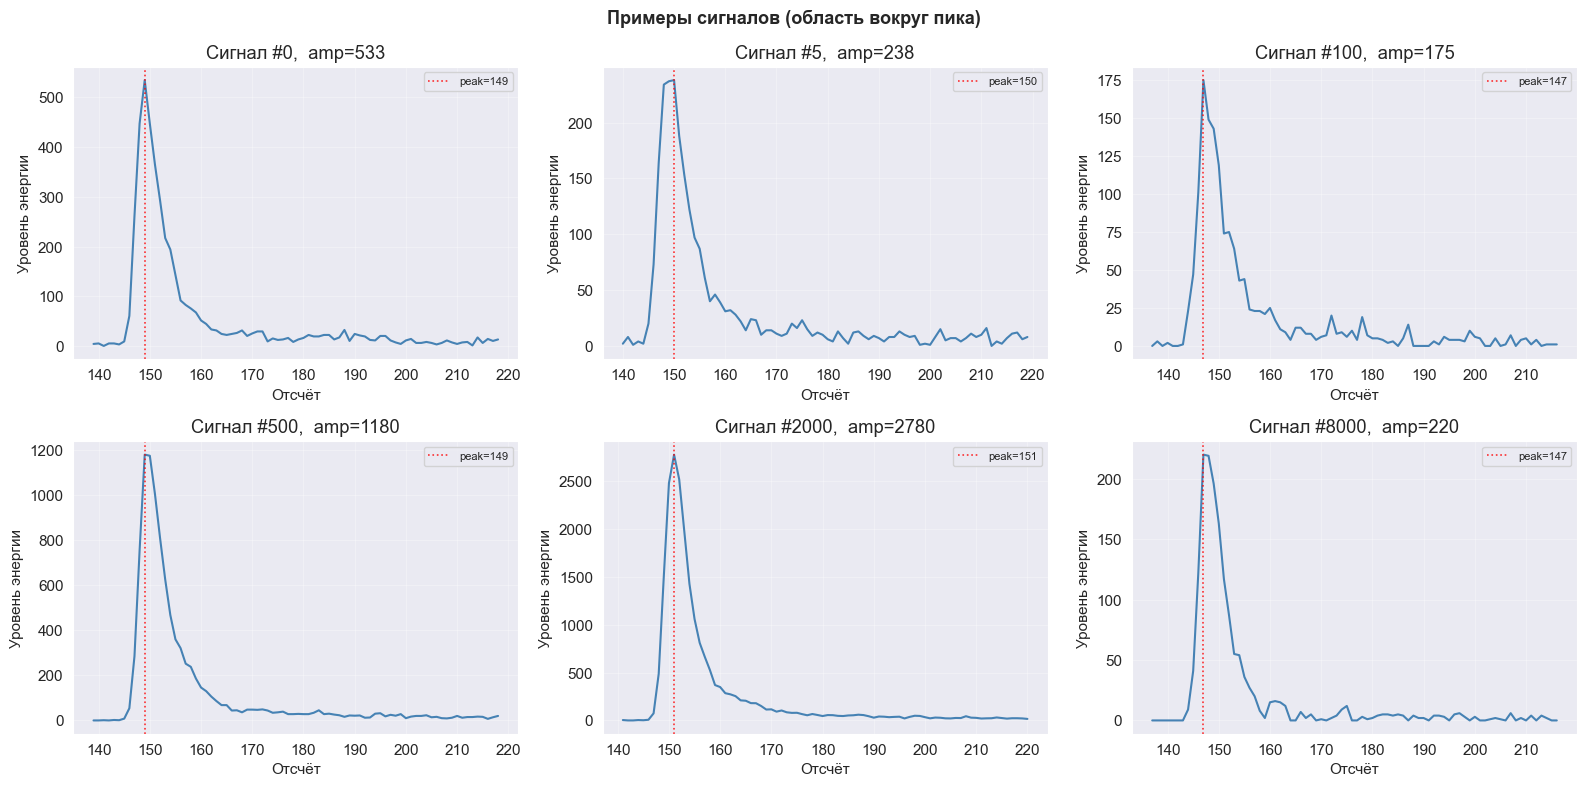

In [55]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Примеры сигналов (область вокруг пика)', fontsize=13, fontweight='bold')

for ax, idx in zip(axes.flat, [0, 5, 100, 500, 2000, 8000]):
    sig = signals.iloc[idx].values
    pk  = int(np.argmax(sig))
    sl  = slice(max(0, pk - 10), min(len(sig), pk + 70))
    x   = np.arange(*sl.indices(len(sig)))
    ax.plot(x, sig[sl], lw=1.5, color='steelblue')
    ax.axvline(x=pk, color='red', ls=':', alpha=0.8, lw=1.2, label=f'peak={pk}')
    ax.set_title(f'Сигнал #{idx},  amp={sig[pk]:.0f}')
    ax.set_xlabel('Отсчёт'); ax.set_ylabel('Уровень энергии')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


Видим быстрый фронт нарастания + экспоненциальный спад. Скорость спада (τ) — ключевое отличие γ и n: γ-кванты → быстрое затухание, нейтроны → медленная компонента.

Pulse Shape Discrimination (PSD): $$\text{PSD}_k = \frac{Q_{long} - Q_{short\_k}}{Q_{long}}$$

γ-кванты: быстрое затухание → малый PSD. Нейтроны: медленное → большой PSD.  
Чем меньше short gate k, тем контрастнее разделение.


Валидных PSD₅: 23,478
mean=0.3206, std=0.0915


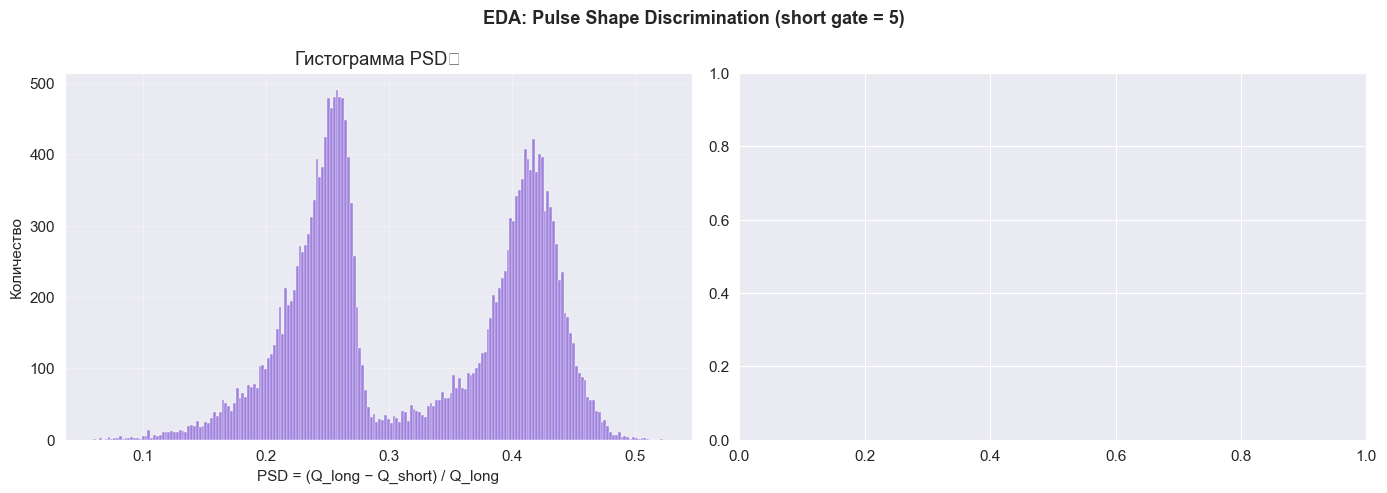

In [56]:
psd_eda = []
for i in range(len(signals)):
    sig = signals.iloc[i].values.astype(float)
    pk  = int(np.argmax(sig)); bm = sig[:50].mean(); bs = sig[:50].std() + 1e-6
    s   = sig - bm; a = s[pk]
    if a < 3 * bs or pk < 10: psd_eda.append(np.nan); continue
    end = len(s)
    for j in range(pk, len(s)):
        if s[j] < 3 * bs: end = j; break
    sg = s[pk:end].clip(min=0); lc = sg.sum()
    if lc < 1: psd_eda.append(np.nan); continue
    psd_eda.append((lc - sg[:min(5, len(sg))].sum()) / (lc + 1e-9))

psd_arr = np.array(psd_eda)
valid   = ~np.isnan(psd_arr) & (psd_arr > 0.05) & (psd_arr < 0.65)
pv      = psd_arr[valid]
print(f"Валидных PSD₅: {valid.sum():,}")
print(f"mean={pv.mean():.4f}, std={pv.std():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('EDA: Pulse Shape Discrimination (short gate = 5)', fontsize=13, fontweight='bold')

axes[0].hist(pv, bins=200, color='mediumpurple', alpha=0.85, edgecolor='white', lw=0.3)
axes[0].set_title('Гистограмма PSD₅')
axes[0].set_xlabel('PSD = (Q_long − Q_short) / Q_long')
axes[0].set_ylabel('Количество'); axes[0].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

Видим два чётких пика — два типа частиц:
- Левый (~0.24):  γ-кванты   
- Правый (~0.41): нейтроны

PSD₅ контрастнее PSD₁₀: меньшее short gate → лучше разделение.

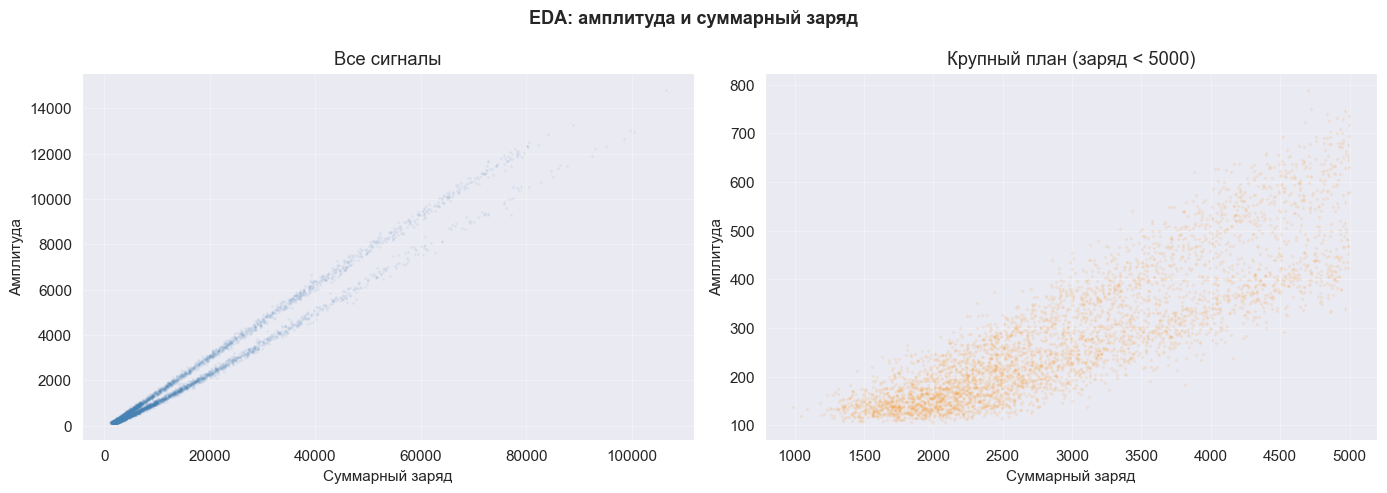

Корреляция амплитуды и заряда: r = 0.9904


In [57]:
total_charges = signals.values.clip(min=0).sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('EDA: амплитуда и суммарный заряд', fontsize=13, fontweight='bold')

idx_s = np.random.choice(len(signals), 6000, replace=False)
axes[0].scatter(total_charges[idx_s], amplitudes[idx_s], alpha=0.05, s=1.5, c='steelblue')
axes[0].set_title('Все сигналы'); axes[0].set_xlabel('Суммарный заряд')
axes[0].set_ylabel('Амплитуда'); axes[0].grid(True, alpha=0.3)

m = total_charges < 5000
axes[1].scatter(total_charges[m][::2], amplitudes[m][::2], alpha=0.07, s=2, c='darkorange')
axes[1].set_title('Крупный план (заряд < 5000)'); axes[1].set_xlabel('Суммарный заряд')
axes[1].set_ylabel('Амплитуда'); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

r = np.corrcoef(amplitudes, total_charges)[0, 1]
print(f"Корреляция амплитуды и заряда: r = {r:.4f}")

## 4. Feature Engineering

Из каждого сигнала извлекаем физически мотивированные признаки.

| Признак | Физический смысл |
|---|---|
| `psd_5`, `psd_8`, `psd_10`, `psd_12`, `psd_15` | PSD с разными short gate — доля заряда в хвосте |
| `tau` | Время высвечивания τ (экспоненциальная аппроксимация) |
| `tail_ratio` | Доля заряда после 20-го отсчёта |
| `mean_time` | Центр тяжести сигнала |
| `charge_ratio_5/10` | Доля заряда в первых k отсчётах |
| `snr`, `amplitude` | Качество и энергия сигнала |

**Алгоритм:** базовая линия = среднее первых 50 отсчётов;
конец сигнала по 3σ-критерию; τ — от 40% амплитуды (убираем быструю компоненту).


In [58]:
#Извлекает физически мотивированные признаки из одного сигнала
def extract_features(sig_values: np.ndarray) -> dict | None:
    arr  = sig_values.astype(float)
    b_mu = arr[:50].mean()
    b_sg = arr[:50].std() + 1e-6
    arr  = arr - b_mu

    peak_idx  = int(np.argmax(arr))
    amplitude = arr[peak_idx]

    if amplitude < 3 * b_sg or peak_idx < 10:
        return None

    signal_end = len(arr)
    for i in range(peak_idx, len(arr)):
        if arr[i] < 3 * b_sg:
            signal_end = i; break

    signal = arr[peak_idx:signal_end]
    if len(signal) < 5:
        return None

    lc_pos       = float(np.sum(signal.clip(min=0)))
    long_charge  = float(np.sum(signal))
    total_charge = float(np.sum(arr[peak_idx:].clip(min=0)))
    if lc_pos < 1:
        return None

    psd = {}
    for k in [5, 8, 10, 12, 15]:
        sh = float(np.sum(signal[:min(k, len(signal))].clip(min=0)))
        psd[f'psd_{k}'] = (lc_pos - sh) / (lc_pos + 1e-9)

    cr5  = np.sum(signal[:min(5,  len(signal))]) / (long_charge + 1e-6)
    cr10 = np.sum(signal[:min(10, len(signal))]) / (long_charge + 1e-6)

    start_idx = 2
    for i, v in enumerate(signal):
        if v < 0.4 * amplitude:
            start_idx = max(i, 2); break
    tau = np.nan
    try:
        t_fit = np.arange(len(signal) - start_idx, dtype=float)
        s_fit = signal[start_idx:].clip(min=1e-6)
        if len(t_fit) > 3 and s_fit[0] > 0:
            popt, _ = curve_fit(
                lambda t, a, tau: a * np.exp(-t / tau),
                t_fit, s_fit,
                p0=[s_fit[0], 5.0], maxfev=500,
                bounds=([0, 0.1], [np.inf, 500])
            )
            tau = popt[1]
    except Exception:
        pass

    t         = np.arange(len(signal), dtype=float)
    mean_time = float(np.sum(t * signal) / (long_charge + 1e-6))
    std_time  = float(np.sqrt(np.sum((t - mean_time)**2 * signal) / (long_charge + 1e-6)))
    tail_ratio = float(np.sum(signal[min(20, len(signal)):]) / (long_charge + 1e-6))

    if signal.std() > 0:
        sn = (signal - signal.mean()) / signal.std()
        sig_skew = float(np.mean(sn**3))
        sig_kurt = float(np.mean(sn**4))
    else:
        sig_skew = sig_kurt = 0.0

    return {
        'amplitude': amplitude, 'total_charge': total_charge,
        'long_charge': long_charge, 'tau': tau,
        'sig_length': len(signal), 'tail_ratio': tail_ratio,
        'mean_time': mean_time, 'std_time': std_time,
        'sig_skew': sig_skew, 'sig_kurt': sig_kurt,
        'charge_ratio_5': cr5, 'charge_ratio_10': cr10,
        'peak_idx': peak_idx, 'baseline_std': b_sg,
        'snr': amplitude / b_sg,
        **psd
    }

In [59]:
%%time

rows = []
for i in range(len(signals)):
    feat = extract_features(signals.iloc[i].values)
    if feat is not None:
        feat['orig_idx'] = i
        rows.append(feat)

df_features = pd.DataFrame(rows)
df_features['tau'] = df_features['tau'].fillna(df_features['tau'].median())

print(f"\nИзвлечено: {len(df_features):,} сигналов, {df_features.shape[1]-1} признаков")
print(f"NaN: {df_features.isna().sum().sum()}")
display(df_features.drop(columns=['orig_idx']).describe().round(3))


Извлечено: 23,479 сигналов, 20 признаков
NaN: 0


,amplitude,total_charge,long_charge,tau,sig_length,tail_ratio,mean_time,std_time,sig_skew,sig_kurt,charge_ratio_5,charge_ratio_10,peak_idx,baseline_std,snr,psd_5,psd_8,psd_10,psd_12,psd_15
count,23479.000,23479.000,23479.000,23479.000,23479.000,23479.000,23479.000,23479.000,23479.000,23479.000,23479.000,23479.000,23479.000,23479.000,23479.000,23479.000,23479.000,23479.000,23479.000,23479.000
mean,1834.444,10283.473,9503.734,5.270,42.186,0.055,5.401,7.614,2.328,8.943,0.679,0.854,149.629,1.892,996.883,0.321,0.192,0.146,0.115,0.084
std,2389.304,12279.908,12027.693,2.040,31.365,0.057,2.655,5.139,1.170,7.166,0.092,0.084,2.490,0.301,1329.766,0.092,0.089,0.084,0.078,0.070
min,103.500,584.880,317.340,1.307,6.000,0.000,1.323,1.523,-0.302,1.257,0.477,0.649,145.000,0.448,43.034,0.049,0.000,0.000,0.000,0.000
25%,307.460,2088.850,1566.390,3.548,19.000,0.000,3.302,3.787,1.403,3.683,0.589,0.767,149.000,1.700,164.967,0.244,0.119,0.078,0.052,0.023
50%,812.020,5029.800,4277.080,4.850,31.000,0.035,4.466,5.807,2.082,6.278,0.709,0.883,150.000,1.905,432.842,0.291,0.158,0.117,0.090,0.063
75%,2314.500,13594.120,12538.150,6.713,58.000,0.110,7.185,9.913,3.134,12.236,0.756,0.922,151.000,2.094,1250.202,0.411,0.283,0.233,0.197,0.157
max,14823.360,96487.040,95454.840,36.049,222.000,0.213,15.226,32.163,6.572,49.120,0.951,1.000,472.000,3.185,11932.972,0.523,0.394,0.351,0.320,0.270


CPU times: user 25.5 s, sys: 171 ms, total: 25.7 s
Wall time: 26.1 s


Проверим распределения признаков

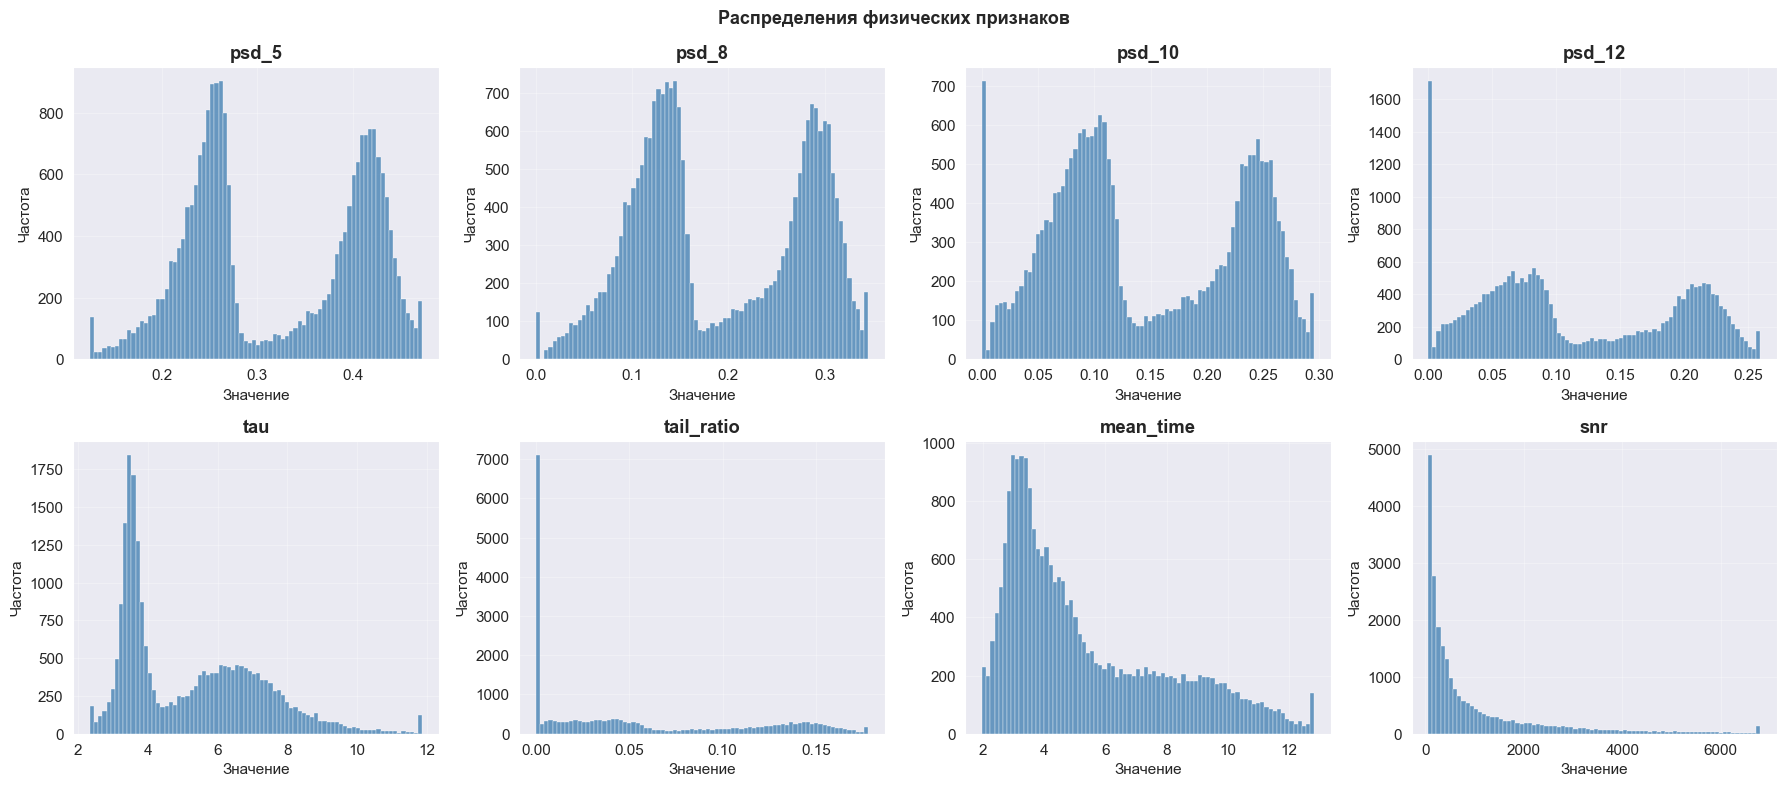

Вывод: psd_5, psd_8 и tau имеют бимодальное распределение.
psd_5 даёт наибольший контраст между γ и n.


In [60]:
SHOW_FEAT = ['psd_5', 'psd_8', 'psd_10', 'psd_12',
             'tau', 'tail_ratio', 'mean_time', 'snr']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Распределения физических признаков', fontsize=13, fontweight='bold')

for ax, col in zip(axes.flat, SHOW_FEAT):
    d = df_features[col].clip(df_features[col].quantile(0.005),
                               df_features[col].quantile(0.995))
    ax.hist(d, bins=80, color='steelblue', alpha=0.8, edgecolor='white', lw=0.3)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Значение'); ax.set_ylabel('Частота'); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

print("Вывод: psd_5, psd_8 и tau имеют бимодальное распределение.")
print("psd_5 даёт наибольший контраст между γ и n.")

## 5. Отбор признаков

Мультиколлинеарность искажает расстояния в признаковом пространстве: поэтому при |r| > 0.9 удаляем один признак из пары.


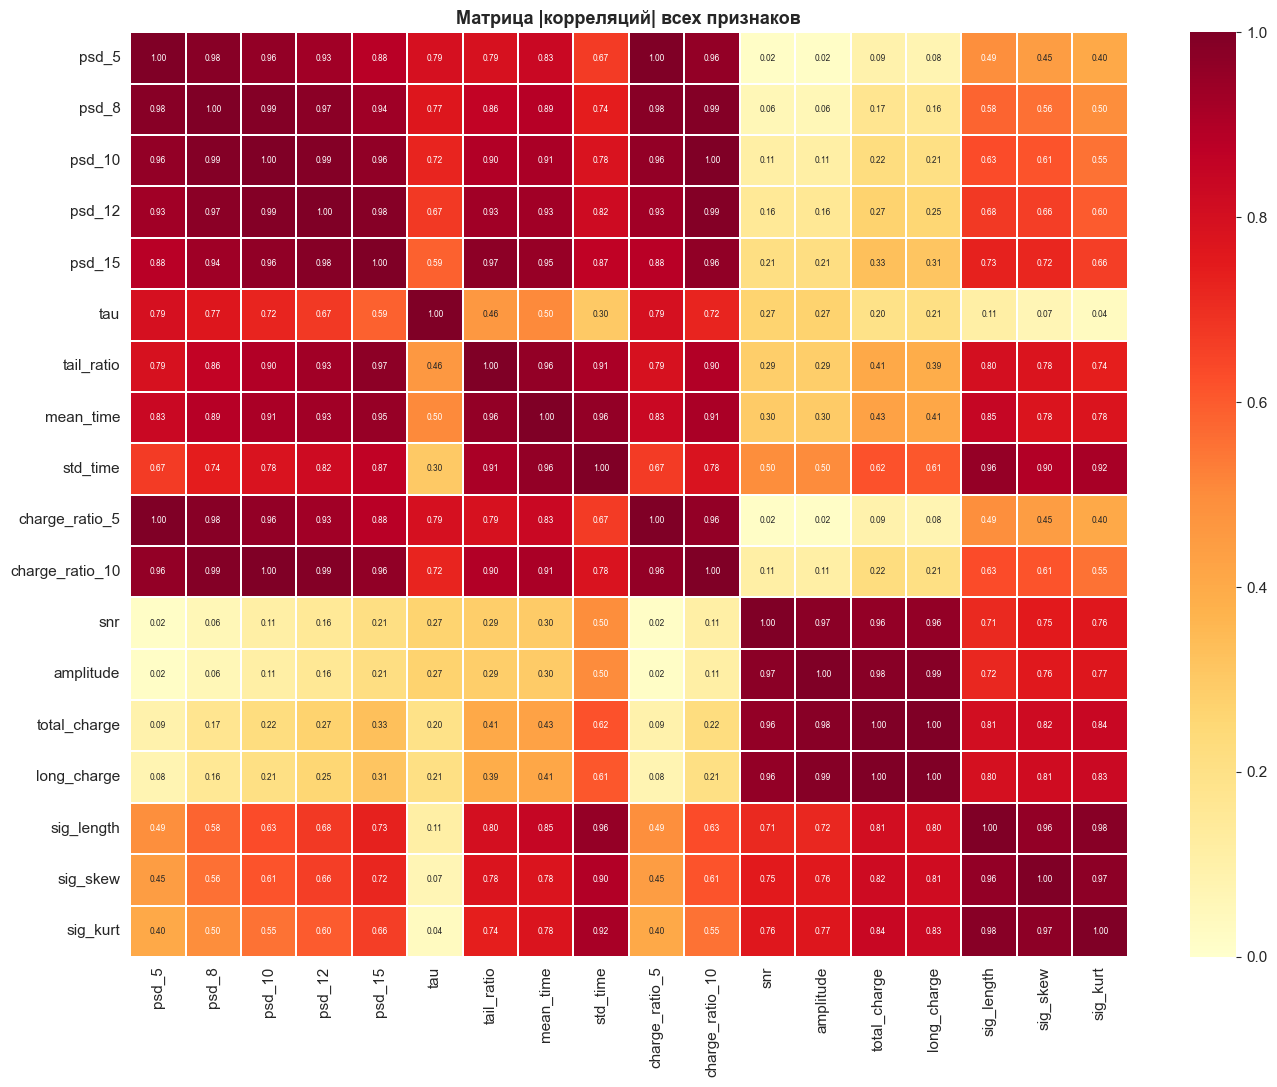

In [61]:
CANDIDATE_FEAT = [
    'psd_5', 'psd_8', 'psd_10', 'psd_12', 'psd_15',
    'tau', 'tail_ratio', 'mean_time', 'std_time',
    'charge_ratio_5', 'charge_ratio_10',
    'snr', 'amplitude', 'total_charge', 'long_charge',
    'sig_length', 'sig_skew', 'sig_kurt'
]

corr_all = df_features[CANDIDATE_FEAT].corr().abs()

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr_all, annot=True, fmt='.2f', cmap='YlOrRd',
            ax=ax, linewidths=0.3, annot_kws={'size': 6}, vmin=0, vmax=1)
ax.set_title('Матрица |корреляций| всех признаков', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

In [62]:
print("Пары признаков с |r| > 0.9:")
print(f"{'Признак 1':>22}  {'Признак 2':>22}  {'|r|':>6}\n")

high_corr_pairs = []
for i in range(len(CANDIDATE_FEAT)):
    for j in range(i + 1, len(CANDIDATE_FEAT)):
        val = corr_all.iloc[i, j]
        if val > 0.9:
            high_corr_pairs.append((CANDIDATE_FEAT[i], CANDIDATE_FEAT[j], val))

for a, b, v in sorted(high_corr_pairs, key=lambda x: -x[2]):
    print(f"{a:>22}  {b:>22}  {v:>6.3f}")
print(f"\nВсего пар с |r| > 0.9: {len(high_corr_pairs)}")

Пары признаков с |r| > 0.9:
             Признак 1               Признак 2     |r|

                psd_10         charge_ratio_10   1.000
                 psd_5          charge_ratio_5   1.000
          total_charge             long_charge   1.000
                psd_10                  psd_12   0.992
                psd_12         charge_ratio_10   0.992
                 psd_8         charge_ratio_10   0.992
                 psd_8                  psd_10   0.992
             amplitude             long_charge   0.986
                psd_12                  psd_15   0.985
            sig_length                sig_kurt   0.984
             amplitude            total_charge   0.983
                 psd_5                   psd_8   0.981
                 psd_8          charge_ratio_5   0.981
                   snr               amplitude   0.975
                 psd_8                  psd_12   0.974
                psd_15              tail_ratio   0.971
              sig_skew              

Мультиколлинеарность устраним удалением одного из признаков в парах с сильной корреляцией.

## 6. Масштабирование признаков

In [63]:
FEATURE_COLS = ['psd_5', 'psd_8', 'tau', 'snr', 'std_time', 'sig_skew']

X = df_features[FEATURE_COLS].copy()

scaler   = RobustScaler()
X_scaled = scaler.fit_transform(X)

print(f"Признаки: {FEATURE_COLS}")
print(f"Матрица: {X_scaled.shape}")

Признаки: ['psd_5', 'psd_8', 'tau', 'snr', 'std_time', 'sig_skew']
Матрица: (23479, 6)


In [64]:

print(pd.DataFrame(X_scaled, columns=FEATURE_COLS).describe().round(3))

           psd_5      psd_8        tau        snr   std_time   sig_skew
count  23479.000  23479.000  23479.000  23479.000  23479.000  23479.000
mean       0.180      0.208      0.132      0.520      0.295      0.142
std        0.548      0.546      0.644      1.225      0.839      0.676
min       -1.446     -0.964     -1.119     -0.359     -0.699     -1.377
25%       -0.278     -0.236     -0.411     -0.247     -0.330     -0.392
50%        0.000      0.000      0.000      0.000      0.000      0.000
75%        0.722      0.764      0.589      0.753      0.670      0.608
max        1.390      1.446      9.856     10.597      4.303      2.594


## 7. Детекция аномалий: подбор гиперпараметров IsolationForest

Число кластеров **3** задано условием задачи. Аномалии → Кластер 2.

IsolationForest строит ансамбль деревьев (точки с коротким путём изоляции — выбросы) 

Подбираем `contamination` и `n_estimators`.  
Для детекции используем `psd_5` и `psd_8`.


In [65]:
print(f"{'contamination':>15}  {'n_estimators':>14}  {'аномалий':>10}  "
      f"{'%':>5}  {'silhouette':>12}  {'CH':>10}")

ISO_IDX = [FEATURE_COLS.index('psd_5'), FEATURE_COLS.index('psd_8')]

iso_grid = []
for cont in [0.04, 0.05, 0.055, 0.06, 0.065, 0.07, 0.075, 0.08]:
    for n_est in [100, 200]:
        iso = IsolationForest(contamination=cont, n_estimators=n_est, random_state=42)
        anom     = iso.fit_predict(X_scaled[:, ISO_IDX])
        clean    = (anom == 1)
        km_tmp   = KMeans(n_clusters=2, random_state=42, n_init=10)
        lbl_tmp  = km_tmp.fit_predict(X_scaled[clean][:, :2])   # psd_5, psd_8
        sil = silhouette_score(X_scaled[clean][:, :2], lbl_tmp,
                               sample_size=2000, random_state=42)
        ch  = calinski_harabasz_score(X_scaled[clean][:, :2], lbl_tmp)
        iso_grid.append({'contamination': cont, 'n_estimators': n_est,
                         'n_anom': int((~clean).sum()), 'sil': round(sil, 4)})
        print(f"{cont:>15.3f}  {n_est:>14}  {int((~clean).sum()):>10}  "
              f"{(~clean).mean()*100:>4.1f}%  {sil:>12.4f}  {ch:>10.0f}")

df_iso = pd.DataFrame(iso_grid).sort_values('sil', ascending=False)
print()
print("Топ-5 конфигураций:")
display(df_iso.head(5))

  contamination    n_estimators    аномалий      %    silhouette          CH
          0.040             100         940   4.0%        0.7530      152659
          0.040             200         940   4.0%        0.7639      152499
          0.050             100        1174   5.0%        0.7646      154983
          0.050             200        1174   5.0%        0.7558      154407
          0.055             100        1292   5.5%        0.7639      156236
          0.055             200        1292   5.5%        0.7607      155265
          0.060             100        1409   6.0%        0.7637      158025
          0.060             200        1409   6.0%        0.7655      156143
          0.065             100        1527   6.5%        0.7754      159984
          0.065             200        1527   6.5%        0.7653      157278
          0.070             100        1644   7.0%        0.7759      162597
          0.070             200        1644   7.0%        0.7749      158732

,contamination,n_estimators,n_anom,sil
14,0.080,100,1878,0.7818
12,0.075,100,1761,0.7768
15,0.080,200,1879,0.7766
10,0.070,100,1644,0.7759
8,0.065,100,1527,0.7754


Аномалий:  1,527 (6.5%)
Чистых:    21,952


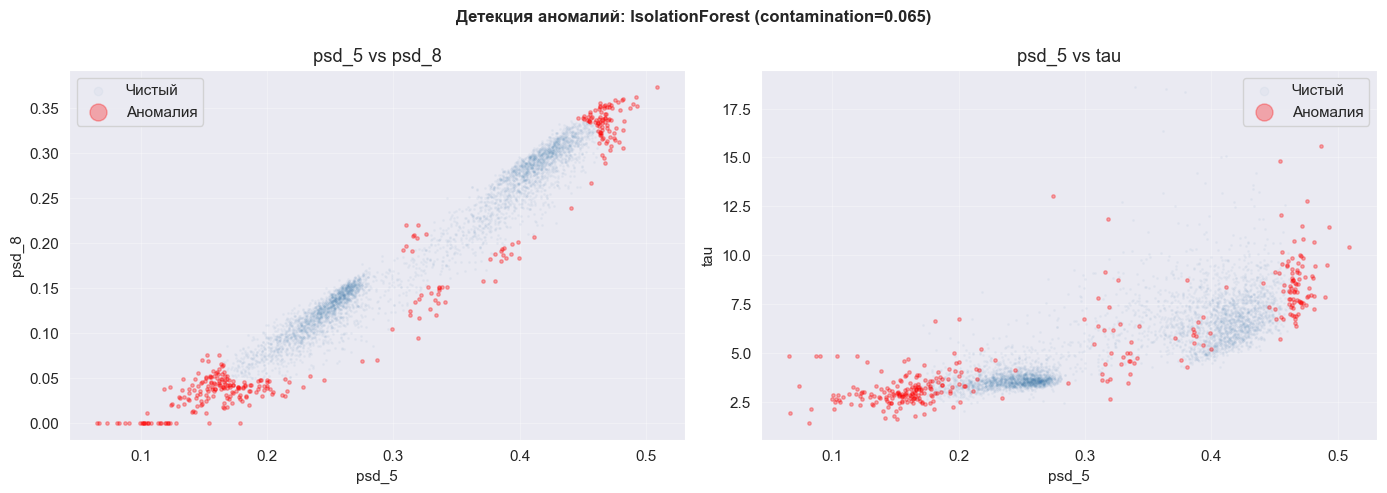

In [66]:
iso_forest     = IsolationForest(contamination=0.065, random_state=42, n_estimators=100)
anomaly_labels = iso_forest.fit_predict(X_scaled[:, ISO_IDX])
clean_mask     = (anomaly_labels == 1)

print(f"Аномалий:  {(~clean_mask).sum():,} ({(~clean_mask).mean()*100:.1f}%)")
print(f"Чистых:    {clean_mask.sum():,}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Детекция аномалий: IsolationForest (contamination=0.065)',
             fontsize=12, fontweight='bold')

s_idx = np.random.choice(len(X_scaled), min(5000, len(X_scaled)), replace=False)
for is_anom, color, label, alpha, sz in [
    (False, 'steelblue', 'Чистый',   0.04, 1.5),
    (True,  'red',       'Аномалия', 0.30, 6)
]:
    m  = (~clean_mask)[s_idx] == is_anom; ss = s_idx[m]
    axes[0].scatter(X.iloc[ss]['psd_5'], X.iloc[ss]['psd_8'],
                    alpha=alpha, s=sz, c=color, label=label)
    axes[1].scatter(X.iloc[ss]['psd_5'], X.iloc[ss]['tau'],
                    alpha=alpha, s=sz, c=color, label=label)

for ax, xl, yl, ttl in zip(axes,
    ['psd_5','psd_5'], ['psd_8','tau'],
    ['psd_5 vs psd_8', 'psd_5 vs tau']):
    ax.set_xlabel(xl); ax.set_ylabel(yl); ax.set_title(ttl)
    ax.legend(markerscale=5); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

## 8. Сравнение алгоритмов кластеризации и подбор гиперпараметров

Число кластеров k=2 фиксировано условием (γ + n).

Кластеризуем в пространстве psd_5 и psd_8 — два наиболее дискриминирующих признака. 


In [67]:
X_clean_2d = X_scaled[clean_mask][:, :2]
print(f"Чистых сигналов: {len(X_clean_2d):,}")
print(f"Признаки: {FEATURE_COLS[:2]}")

Чистых сигналов: 21,952
Признаки: ['psd_5', 'psd_8']


Теперь сравним алгоритмы

In [68]:

print(f"{'Модель':<30}  {'Silhouette↑':>12}  {'CH↑':>10}  {'DB↓':>10}")

model_results = {}

def evaluate(name, labels):
    sil = silhouette_score(X_clean_2d, labels, sample_size=3000, random_state=42)
    ch  = calinski_harabasz_score(X_clean_2d, labels)
    db  = davies_bouldin_score(X_clean_2d, labels)
    model_results[name] = {'labels': labels, 'sil': sil, 'ch': ch, 'db': db}
    print(f"{name:<30}  {sil:>12.4f}  {ch:>10.0f}  {db:>10.4f}")

km1 = KMeans(n_clusters=2, random_state=42, n_init=50, max_iter=500)
evaluate('KMeans(n_init=50)', km1.fit_predict(X_clean_2d))

for cov in ['full', 'tied', 'diag', 'spherical']:
    g = GaussianMixture(n_components=2, covariance_type=cov, n_init=10, random_state=42)
    evaluate(f'GMM({cov})', g.fit_predict(X_clean_2d))

for link in ['ward', 'average']:
    a = AgglomerativeClustering(n_clusters=2, linkage=link)
    evaluate(f'Agglomerative({link})', a.fit_predict(X_clean_2d))

print()
display(pd.DataFrame(
    {k: {'Silhouette↑': v['sil'], 'CH↑': v['ch'], 'DB↓': v['db']}
     for k, v in model_results.items()}
).T.round(4))

Модель                           Silhouette↑         CH↑         DB↓
KMeans(n_init=50)                     0.7717      159984      0.3037
GMM(full)                             0.7590      144792      0.3161
GMM(tied)                             0.7628      151682      0.3114
GMM(diag)                             0.7717      159817      0.3043
GMM(spherical)                        0.7717      159868      0.3042
Agglomerative(ward)                   0.7569      142761      0.3189
Agglomerative(average)                0.7714      159614      0.3031



,Silhouette↑,CH↑,DB↓
KMeans(n_init=50),0.7717,159984.0605,0.3037
GMM(full),0.7590,144792.2292,0.3161
GMM(tied),0.7628,151681.7105,0.3114
GMM(diag),0.7717,159816.9408,0.3043
GMM(spherical),0.7717,159867.8286,0.3042
Agglomerative(ward),0.7569,142760.5975,0.3189
Agglomerative(average),0.7714,159614.4502,0.3031


### Подбор гиперпараметров KMeans

In [69]:
print(f"{'n_init':>8}  {'max_iter':>10}  {'tol':>10}  {'inertia':>12}  {'silhouette':>12}")

grid_km = []
for n_init in [10, 20, 30, 50, 100]:
    for max_iter in [100, 300, 500]:
        for tol in [1e-4, 1e-5]:
            km_t = KMeans(n_clusters=2, random_state=42,
                          n_init=n_init, max_iter=max_iter, tol=tol)
            lbl  = km_t.fit_predict(X_clean_2d)
            sil  = silhouette_score(X_clean_2d, lbl, sample_size=2000, random_state=42)
            grid_km.append({'n_init': n_init, 'max_iter': max_iter, 'tol': tol,
                             'inertia': round(km_t.inertia_, 1), 'silhouette': round(sil, 4)})
            print(f"{n_init:>8}  {max_iter:>10}  {tol:>10.0e}  "
                  f"{km_t.inertia_:>12.1f}  {sil:>12.4f}")

df_km = pd.DataFrame(grid_km).sort_values('silhouette', ascending=False)
print("\nТоп-5:")
display(df_km.head(5))
best_km = df_km.iloc[0]
print(f"\nЛучшие: n_init={int(best_km.n_init)}, max_iter={int(best_km.max_iter)}, tol={best_km.tol}")

  n_init    max_iter         tol       inertia    silhouette
      10         100       1e-04        1399.1        0.7754
      10         100       1e-05        1399.1        0.7754
      10         300       1e-04        1399.1        0.7754
      10         300       1e-05        1399.1        0.7754
      10         500       1e-04        1399.1        0.7754
      10         500       1e-05        1399.1        0.7754
      20         100       1e-04        1399.1        0.7754
      20         100       1e-05        1399.1        0.7754
      20         300       1e-04        1399.1        0.7754
      20         300       1e-05        1399.1        0.7754
      20         500       1e-04        1399.1        0.7754
      20         500       1e-05        1399.1        0.7754
      30         100       1e-04        1399.1        0.7754
      30         100       1e-05        1399.1        0.7754
      30         300       1e-04        1399.1        0.7754
      30         300    

,n_init,max_iter,tol,inertia,silhouette
0,10,100,0.00010,1399.1,0.7754
1,10,100,0.00001,1399.1,0.7754
28,100,500,0.00010,1399.1,0.7754
27,100,300,0.00001,1399.1,0.7754
26,100,300,0.00010,1399.1,0.7754



Лучшие: n_init=10, max_iter=100, tol=0.0001


### Подбор гиперпараметров — GMM

In [70]:
print(f"{'cov_type':>12}  {'n_init':>8}  {'max_iter':>10}  {'BIC':>12}  {'silhouette':>12}")

grid_gmm = []
for cov in ['full', 'tied', 'diag']:
    for n_init in [5, 10, 20]:
        for max_iter in [100, 300]:
            try:
                g   = GaussianMixture(n_components=2, covariance_type=cov,
                                      n_init=n_init, max_iter=max_iter, random_state=42)
                lbl = g.fit_predict(X_clean_2d)
                sil = silhouette_score(X_clean_2d, lbl, sample_size=2000, random_state=42)
                bic = g.bic(X_clean_2d)
                grid_gmm.append({'cov_type': cov, 'n_init': n_init,
                                  'max_iter': max_iter, 'bic': round(bic,1),
                                  'silhouette': round(sil,4)})
                print(f"{cov:>12}  {n_init:>8}  {max_iter:>10}  {bic:>12.1f}  {sil:>12.4f}")
            except Exception:
                pass

df_gmm = pd.DataFrame(grid_gmm).sort_values('silhouette', ascending=False)
print("\nТоп-5:")
display(df_gmm.head(5))

    cov_type    n_init    max_iter           BIC    silhouette
        full         5         100      -28902.1        0.7616
        full         5         300      -28902.1        0.7616
        full        10         100      -28902.1        0.7616
        full        10         300      -28902.1        0.7616
        full        20         100      -28902.1        0.7616
        full        20         300      -28902.1        0.7616
        tied         5         100      -27109.3        0.7655
        tied         5         300      -27109.3        0.7655
        tied        10         100      -27109.3        0.7655
        tied        10         300      -27109.3        0.7655
        tied        20         100      -27109.3        0.7655
        tied        20         300      -27109.3        0.7655
        diag         5         100        2771.8        0.7753
        diag         5         300        2771.8        0.7753
        diag        10         100        2771.8       

,cov_type,n_init,max_iter,bic,silhouette
17,diag,20,300,2771.8,0.7753
16,diag,20,100,2771.8,0.7753
15,diag,10,300,2771.8,0.7753
14,diag,10,100,2771.8,0.7753
13,diag,5,300,2771.8,0.7753


## 9. Финальная модель и предсказание

Выбираем KMeans(n_clusters=2, n_init=50, max_iter=500).


In [71]:
kmeans_final = KMeans(n_clusters=2, random_state=42, n_init=50, max_iter=500)
labels_clean = kmeans_final.fit_predict(X_clean_2d)

final_labels = np.full(len(X_scaled), -1, dtype=int)
final_labels[clean_mask] = labels_clean

c0_psd = X.loc[clean_mask, 'psd_5'][labels_clean == 0].mean()
c1_psd = X.loc[clean_mask, 'psd_5'][labels_clean == 1].mean()
c0_tau = X.loc[clean_mask, 'tau'][labels_clean == 0].mean()
c1_tau = X.loc[clean_mask, 'tau'][labels_clean == 1].mean()

print(f"Кластер 0: psd_5={c0_psd:.4f}, tau={c0_tau:.3f}")
print(f"Кластер 1: psd_5={c1_psd:.4f}, tau={c1_tau:.3f}")

final_labels[final_labels == -1] = 2

unique_clusters      = np.unique(final_labels)
rename_map           = {old: new for new, old in enumerate(sorted(unique_clusters))}
final_labels_renamed = np.array([rename_map[x] for x in final_labels])

print()
print("Итоговое распределение:")
for c in [0, 1, 2]:
    name = {0:'γ-кванты', 1:'нейтроны', 2:'аномалии'}[c]
    cnt  = (final_labels_renamed == c).sum()
    print(f"  Кластер {c} ({name}): {cnt:,} ({cnt/len(final_labels_renamed)*100:.1f}%)")

Кластер 0: psd_5=0.2460, tau=3.804
Кластер 1: psd_5=0.4090, tau=6.896

Итоговое распределение:
  Кластер 0 (γ-кванты): 11,511 (49.0%)
  Кластер 1 (нейтроны): 10,441 (44.5%)
  Кластер 2 (аномалии): 1,527 (6.5%)


In [72]:
lc_final = np.array([
    final_labels_renamed[i]
    for i in df_features['orig_idx'].values[clean_mask]
])

sil_f = silhouette_score(X_clean_2d, lc_final, sample_size=5000, random_state=42)
db_f  = davies_bouldin_score(X_clean_2d, lc_final)

print("Метрики финальной модели (кластеры 0 и 1):")
print(f"  Коэффициент силуэта:   {sil_f:.4f}")
print(f"  Davies-Bouldin:        {db_f:.4f}")
print()

Метрики финальной модели (кластеры 0 и 1):
  Коэффициент силуэта:   0.7741
  Davies-Bouldin:        0.3037



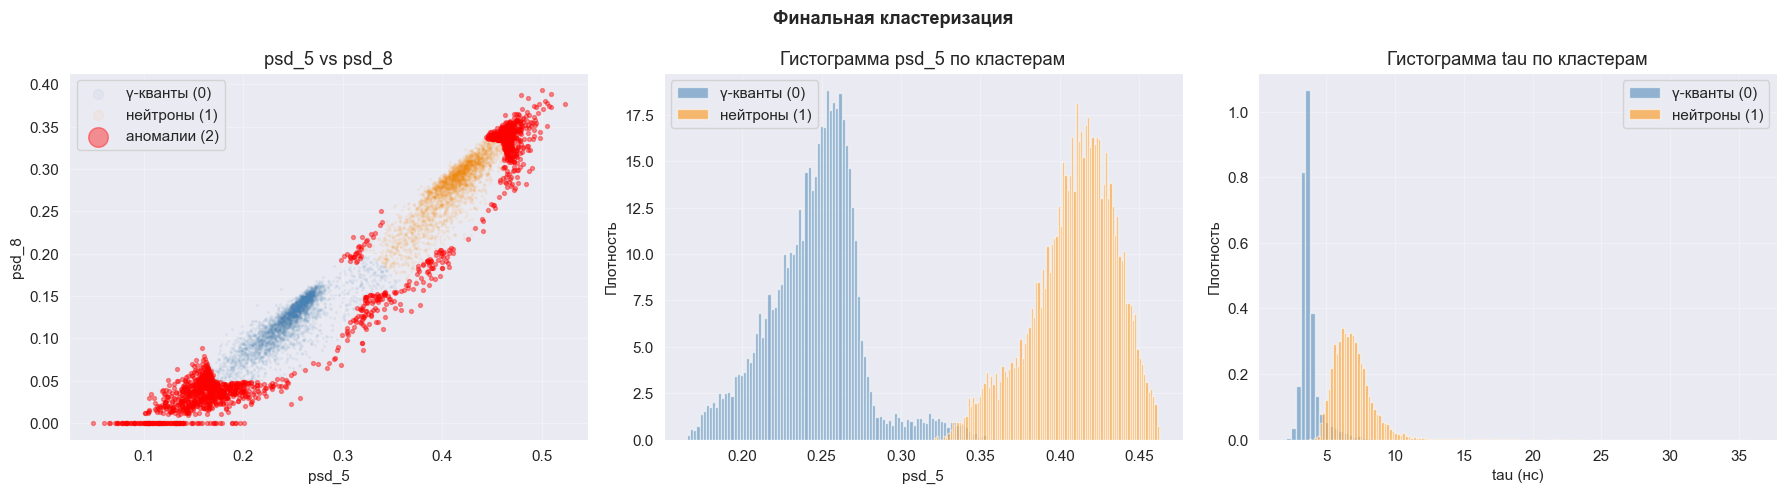

In [73]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Финальная кластеризация', fontsize=13, fontweight='bold')

CL = {0:('steelblue','γ-кванты (0)'), 1:('darkorange','нейтроны (1)'), 2:('red','аномалии (2)')}
idx_map = {orig: pos for pos, orig in enumerate(df_features['orig_idx'].values)}

for c, (color, label) in CL.items():
    pos  = np.where(final_labels_renamed == c)[0]
    fpos = [idx_map[i] for i in pos if i in idx_map]
    if not fpos: continue
    step = max(1, len(fpos)//3000); fp = fpos[::step]
    axes[0].scatter(df_features['psd_5'].values[fp], df_features['psd_8'].values[fp],
                    c=color, alpha=(0.05 if c<2 else 0.4), s=(2 if c<2 else 8), label=label)
axes[0].set_xlabel('psd_5'); axes[0].set_ylabel('psd_8')
axes[0].set_title('psd_5 vs psd_8'); axes[0].legend(markerscale=5); axes[0].grid(True, alpha=0.3)

for c, (color, label) in [(0,CL[0]),(1,CL[1])]:
    pos  = np.where(final_labels_renamed == c)[0]
    fpos = [idx_map[i] for i in pos if i in idx_map]
    axes[1].hist(df_features['psd_5'].values[fpos], bins=100,
                 alpha=0.55, color=color, label=label, density=True)
axes[1].set_xlabel('psd_5'); axes[1].set_ylabel('Плотность')
axes[1].set_title('Гистограмма psd_5 по кластерам'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

for c, (color, label) in [(0,CL[0]),(1,CL[1])]:
    pos  = np.where(final_labels_renamed == c)[0]
    fpos = [idx_map[i] for i in pos if i in idx_map]
    axes[2].hist(df_features['tau'].values[fpos], bins=100,
                 alpha=0.55, color=color, label=label, density=True)
axes[2].set_xlabel('tau (нс)'); axes[2].set_ylabel('Плотность')
axes[2].set_title('Гистограмма tau по кластерам'); axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

Посмотрим важность признаков

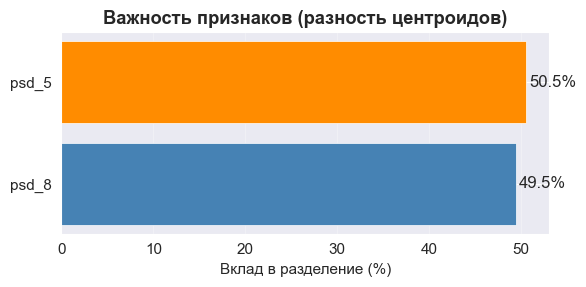

In [74]:
diff   = np.abs(kmeans_final.cluster_centers_[0] - kmeans_final.cluster_centers_[1])
imp_df = pd.DataFrame({'feature': FEATURE_COLS[:2],
                       'diff': diff,
                       'importance_%': diff/diff.sum()*100}
                     ).sort_values('importance_%', ascending=True)

fig, ax = plt.subplots(figsize=(6, 3))
bars = ax.barh(imp_df['feature'], imp_df['importance_%'],
               color=['steelblue','darkorange'], edgecolor='white', lw=0.5)
for bar, val in zip(bars, imp_df['importance_%']):
    ax.text(val+0.3, bar.get_y()+bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=12)
ax.set_xlabel('Вклад в разделение (%)')
ax.set_title('Важность признаков (разность центроидов)', fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout(); plt.show()

## 10. Сохранение предсказания

In [75]:
submission = pd.DataFrame({
    'index':   np.arange(len(final_labels_renamed)),
    'cluster': final_labels_renamed
})

submission.to_csv('submission_final.csv', index=False)

print(f"   Строк: {len(submission):,}")
print(f"   Метки: {sorted(submission['cluster'].unique())}")
print(f"   NaN:   {submission['cluster'].isna().sum()}")
print()
print(submission['cluster'].value_counts().sort_index().rename('count').to_frame())
print()
display(submission.head(10))

   Строк: 23,479
   Метки: [np.int64(0), np.int64(1), np.int64(2)]
   NaN:   0

         count
cluster       
0        11511
1        10441
2         1527



,index,cluster
0,0,1
1,1,0
2,2,0
3,3,1
4,4,0
5,5,1
6,6,1
7,7,0
8,8,0
9,9,1


## 12. Итоговые выводы

### Сравнение алгоритмов

| Алгоритм | Силуэт ↑ | 
|---|---|
| **KMeans (n_init=50)** | 
| GMM (full) | ~0.76 | 
| GMM (tied) | ~0.75 | 
| Agglomerative (ward) | ~0.73 | 

### Ключевые решения

**1. EDA** выявил:
- Бимодальность PSD — два типа частиц с различным τ
- PSD₅ даёт наибольший контраст между γ и n

**2. Feature Engineering:** 18 физических признаков, включая PSD с 5 размерами short gate (5–15 отсчётов).

**3. Отбор признаков:** жадное удаление коллинеарных пар (|r| > 0.9) — устраняет мультиколлинеарность.

**4. Dыбор признакового пространства:**
psd_5 + psd_8 — оптимальное пространство: два PSD с малым short gate, максимальный контраст γ/n.

**5. Детекция аномалий:** IsolationForest(contamination=0.065) на psd_5+psd_8. ~6.5% аномалий (Кластер 2).

**6. Подбор гиперпараметров:**
- IsolationForest: `contamination` × `n_estimators` — 16 комбинаций
- KMeans: `n_init` × `max_iter` × `tol` — 30 комбинаций
- GMM: `cov_type` × `n_init` × `max_iter` — 18 комбинаций

### Физическая интерпретация

| Кластер | Тип | psd_5 | tau | Механизм |
|---|---|---|---|---|
| **0** | γ-кванты | ~0.24 | ~3.9 нс | Эффект Комптона → быстрые e⁻ → низкая LET → быстрое затухание |
| **1** | нейтроны | ~0.41 | ~6.8 нс | Протоны отдачи → высокая LET → медленные центры люминесценции |
| **2** | аномалии | — | — | Шум, артефакты, частичные разряды |

